In [1]:
%matplotlib inline
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Add, AveragePooling2D, BatchNormalization, Concatenate, Conv2D, Dense, Dropout, GlobalAveragePooling1D, GlobalAveragePooling2D, Input, LayerNormalization, MultiHeadAttention, Reshape
from tensorflow.keras.optimizers import Adam

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FEATURES_PATH = PROJECT_ROOT / "dataset" / "features_3.0_sec.json"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)
print(FEATURES_PATH)

C:\Users\Muham\Desktop\Data (1)\music-genre-classification
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\dataset\features_3.0_sec.json


In [2]:
with FEATURES_PATH.open("r", encoding="utf-8") as fp:
    data = json.load(fp)

X = np.array(data["mfcc"], dtype=np.float32)
y = np.array(data["genre_num"], dtype=np.int64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=SEED, stratify=y_train)

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]
input_shape = X_train.shape[1:]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)
print("Input shape:", input_shape)

X_train: (5594, 132, 13, 1) y_train: (5594,)
X_val: (1399, 132, 13, 1) y_val: (1399,)
X_test: (2997, 132, 13, 1) y_test: (2997,)
Input shape: (132, 13, 1)


In [3]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history["accuracy"], label="training accuracy")
    axes[0].plot(history.history["val_accuracy"], label="validation accuracy")
    axes[0].set_title(title + " - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(history.history["loss"], label="training loss")
    axes[1].plot(history.history["val_loss"], label="validation loss")
    axes[1].set_title(title + " - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def show_confusion_matrix(model, X_current, y_current, title):
    y_pred = np.argmax(model.predict(X_current, verbose=0), axis=1)
    cm = confusion_matrix(y_current, y_pred)
    fig, ax = plt.subplots(figsize=(9, 9))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GENRES)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(classification_report(y_current, y_pred, target_names=GENRES, zero_division=0))
    return y_pred

In [4]:
def dense_layer(x, growth_rate):
    y = BatchNormalization()(x)
    y = tf.keras.layers.Activation("relu")(y)
    y = Conv2D(growth_rate, 3, padding="same")(y)
    return Concatenate()([x, y])


def dense_block(x, layers, growth_rate):
    for _ in range(layers):
        x = dense_layer(x, growth_rate)
    return x


def transition_block(x, filters):
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = Conv2D(filters, 1, padding="same")(x)
    return AveragePooling2D(2, padding="same")(x)


def build_compact_densenet(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = dense_block(x, layers=2, growth_rate=8)
    x = transition_block(x, filters=32)
    x = dense_block(x, layers=2, growth_rate=12)
    x = transition_block(x, filters=40)
    x = dense_block(x, layers=2, growth_rate=16)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.30)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.20)(x)
    outputs = Dense(len(GENRES), activation="softmax")(x)
    return Model(inputs, outputs, name="compact_densenet")


def transformer_block(x, embed_dim, num_heads, mlp_dim, dropout_rate):
    attention_input = LayerNormalization(epsilon=1e-6)(x)
    attention = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads, dropout=dropout_rate)(attention_input, attention_input)
    x = Add()([x, attention])
    mlp_input = LayerNormalization(epsilon=1e-6)(x)
    mlp = Dense(mlp_dim, activation="gelu")(mlp_input)
    mlp = Dropout(dropout_rate)(mlp)
    mlp = Dense(embed_dim)(mlp)
    mlp = Dropout(dropout_rate)(mlp)
    return Add()([x, mlp])


def build_compact_vit(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv2D(48, kernel_size=(11, 2), strides=(11, 2), padding="valid")(inputs)
    token_count = x.shape[1] * x.shape[2]
    x = Reshape((token_count, 48))(x)
    positions = tf.range(start=0, limit=token_count, delta=1)
    position_embedding = tf.keras.layers.Embedding(input_dim=token_count, output_dim=48)(positions)
    x = x + position_embedding
    x = transformer_block(x, embed_dim=48, num_heads=4, mlp_dim=96, dropout_rate=0.15)
    x = LayerNormalization(epsilon=1e-6)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(0.25)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.20)(x)
    outputs = Dense(len(GENRES), activation="softmax")(x)
    return Model(inputs, outputs, name="compact_vit")

Compact DenseNet


Model: "compact_densenet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 132, 13,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 132, 13,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 132, 13,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 132, 13,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 132, 13,   │      2,312 │ activation[0][0]  │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 132, 13,   │          0 │ conv2d[0][0],     │
│ (Concatenate)       │ 40)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 132, 13,   │        160 │ concatenate[0][0] │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 132, 13,   │          0 │ batch_normalizat… │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 132, 13,   │      2,888 │ activation_1[0][… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 132, 13,   │          0 │ concatenate[0][0… │
│ (Concatenate)       │ 48)               │            │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 132, 13,   │        192 │ concatenate_1[0]… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 132, 13,   │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 132, 13,   │      1,568 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d   │ (None, 66, 7, 32) │          0 │ conv2d_3[0][0]    │
│ (AveragePooling2D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 66, 7, 32) │        128 │ average_pooling2… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 66, 7, 32) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 66, 7, 12) │      3,468 │ activation_3[0][

 Total params: 38,458 (150.23 KB)

 Trainable params: 37,618 (146.95 KB)

...

Epoch 19/20


88/88 - 19s - 215ms/step - accuracy: 0.7151 - loss: 0.8197 - val_accuracy: 0.7598 - val_loss: 0.7172 - learning_rate: 5.0000e-04


Epoch 20/20


88/88 - 19s - 211ms/step - accuracy: 0.7311 - loss: 0.8110 - val_accuracy: 0.7255 - val_loss: 0.7981 - learning_rate: 5.0000e-04


Training accuracy: 0.7692
Validation accuracy: 0.7598
Test accuracy: 0.7421
Loss: 0.6686
Validation loss: 0.7172
Test loss: 0.7417


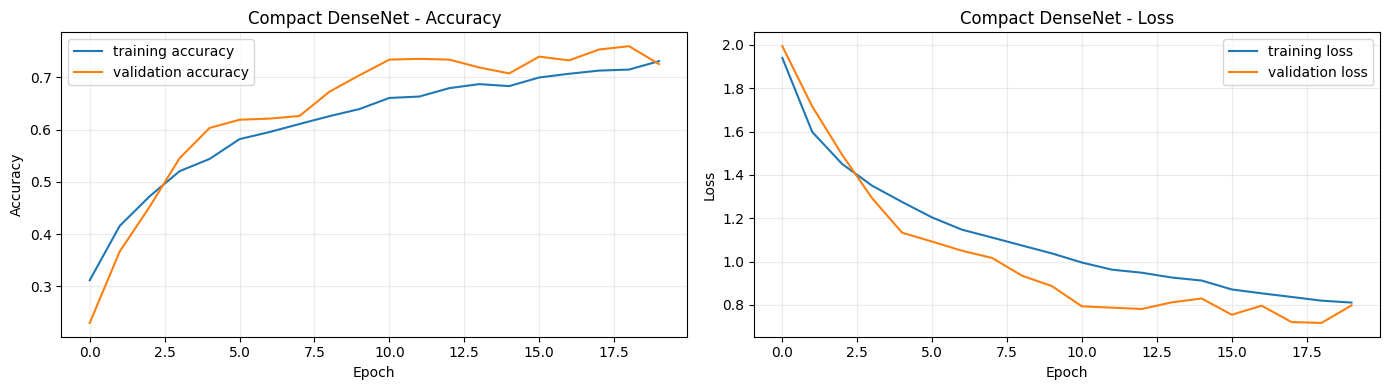

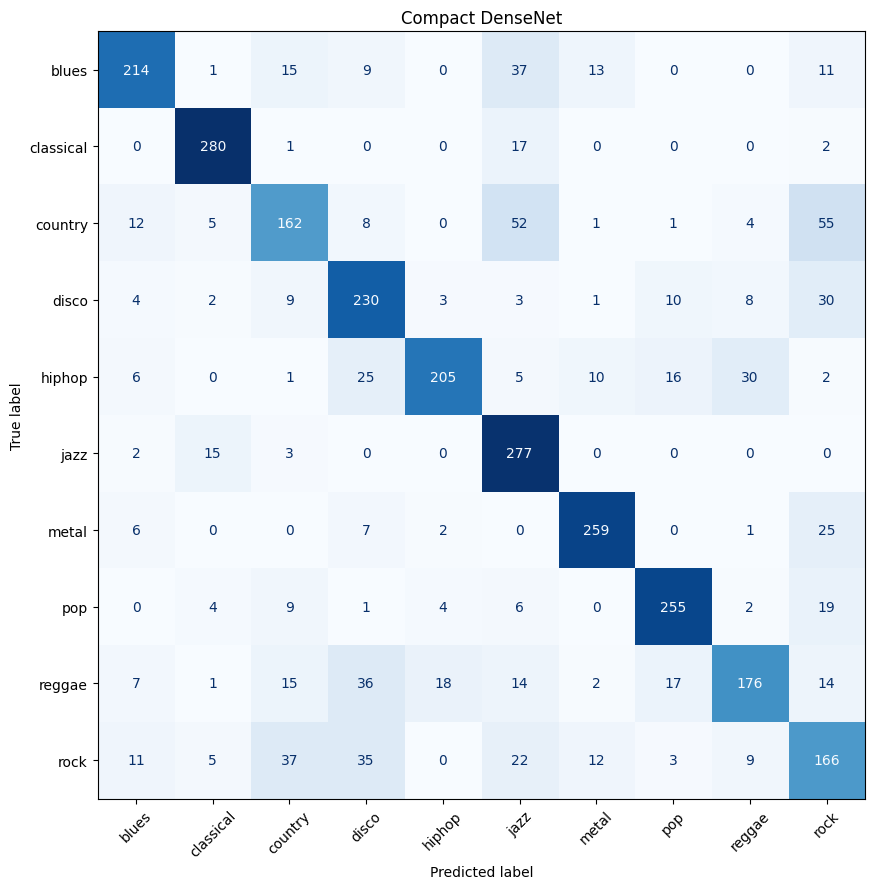

              precision    recall  f1-score   support

       blues       0.82      0.71      0.76       300
   classical       0.89      0.93      0.91       300
     country       0.64      0.54      0.59       300
       disco       0.66      0.77      0.71       300
      hiphop       0.88      0.68      0.77       300
        jazz       0.64      0.93      0.76       297
       metal       0.87      0.86      0.87       300
         pop       0.84      0.85      0.85       300
      reggae       0.77      0.59      0.66       300
        rock       0.51      0.55      0.53       300

    accuracy                           0.74      2997
   macro avg       0.75      0.74      0.74      2997
weighted avg       0.75      0.74      0.74      2997

Compact Vision Transformer


Model: "compact_vit"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 132, 13,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 12, 6, 48) │      1,104 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 72, 48)    │          0 │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 72, 48)    │          0 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 72, 48)    │         96 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 72, 48)    │      9,408 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 72, 48)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 48)    │         96 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 72, 96)    │      4,704 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 72, 96)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 72, 48)    │      4,656 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 72, 48)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 72, 48)    │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 48)    │         96 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 48)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      3,136 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10)        │        650 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,946 (93.54 KB)

 Trainable params: 23,946 (93.54 KB)

...

Epoch 19/20


88/88 - 2s - 25ms/step - accuracy: 0.4850 - loss: 1.3772 - val_accuracy: 0.5368 - val_loss: 1.2612 - learning_rate: 5.0000e-04


Epoch 20/20


88/88 - 2s - 24ms/step - accuracy: 0.4948 - loss: 1.3614 - val_accuracy: 0.5332 - val_loss: 1.2567 - learning_rate: 5.0000e-04


Training accuracy: 0.5399
Validation accuracy: 0.5368
Test accuracy: 0.5138
Loss: 1.2615
Validation loss: 1.2612
Test loss: 1.3150


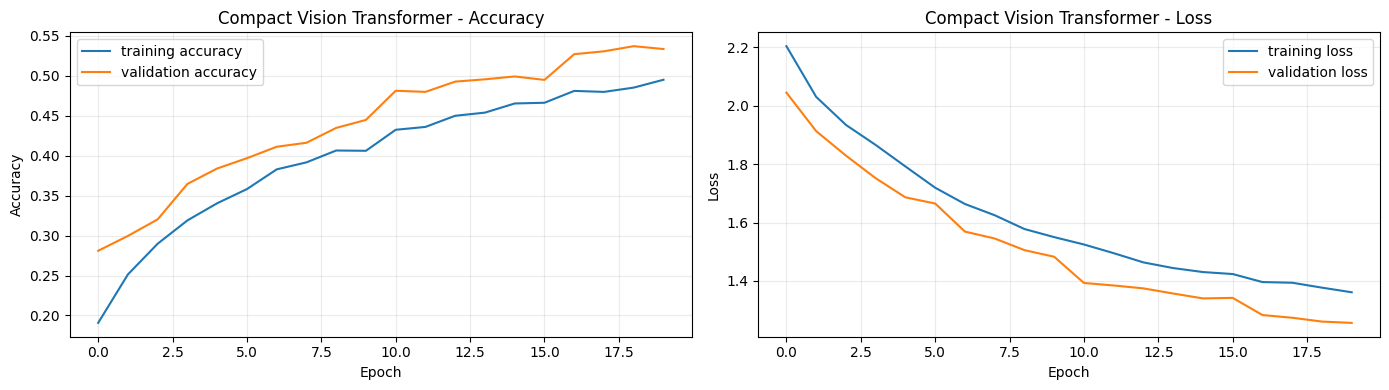

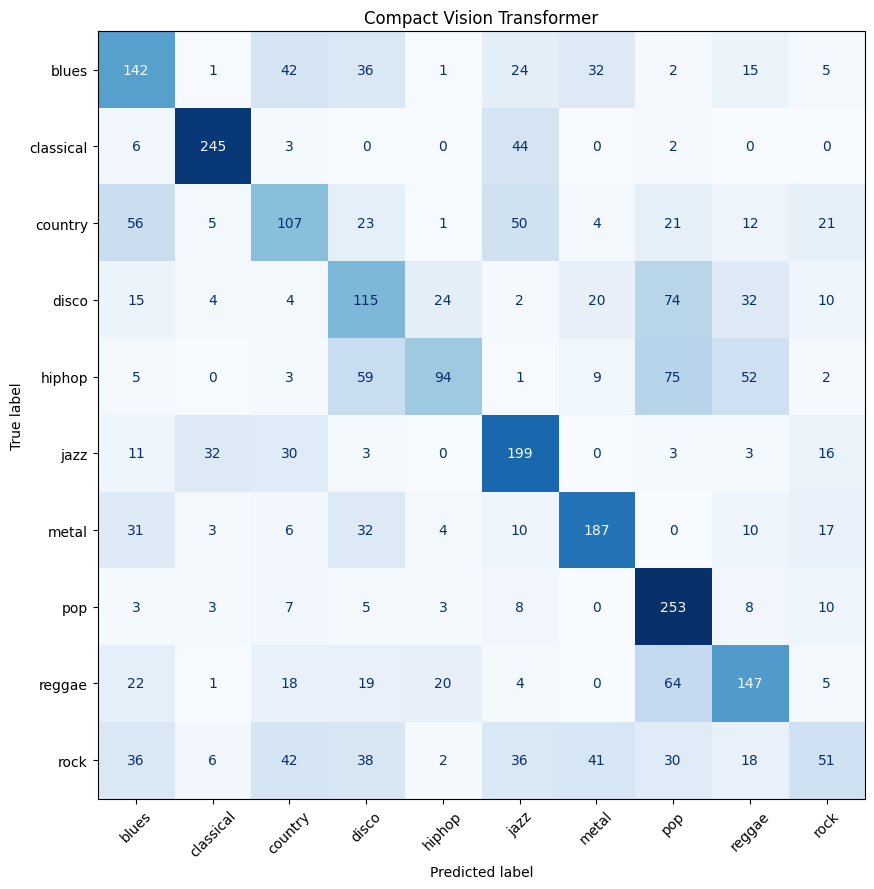

              precision    recall  f1-score   support

       blues       0.43      0.47      0.45       300
   classical       0.82      0.82      0.82       300
     country       0.41      0.36      0.38       300
       disco       0.35      0.38      0.37       300
      hiphop       0.63      0.31      0.42       300
        jazz       0.53      0.67      0.59       297
       metal       0.64      0.62      0.63       300
         pop       0.48      0.84      0.61       300
      reggae       0.49      0.49      0.49       300
        rock       0.37      0.17      0.23       300

    accuracy                           0.51      2997
   macro avg       0.52      0.51      0.50      2997
weighted avg       0.52      0.51      0.50      2997



In [5]:
EPOCHS = 20
BATCH_SIZE = 64
TRIALS = [
    {"label": "Compact DenseNet", "builder": build_compact_densenet, "learning_rate": 0.0005},
    {"label": "Compact Vision Transformer", "builder": build_compact_vit, "learning_rate": 0.0005},
]

results = []
trained_models = {}
histories = {}

for trial in TRIALS:
    model_name = trial["label"]
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    model = trial["builder"](input_shape)
    model.compile(optimizer=Adam(learning_rate=trial["learning_rate"]), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model.summary()
    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
        ModelCheckpoint(MODELS_DIR / f"{model.name}_checkpoint.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks, verbose=2)
    train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    results.append({
        "model": model_name,
        "training_accuracy": train_accuracy,
        "validation_accuracy": val_accuracy,
        "test_accuracy": test_accuracy,
        "loss": train_loss,
        "validation_loss": val_loss,
        "test_loss": test_loss,
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "epochs_run": len(history.history["loss"]),
    })
    trained_models[model_name] = model
    histories[model_name] = history
    model.save(MODELS_DIR / f"{model.name}.keras")
    model.save(MODELS_DIR / f"{model.name}.h5")
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Validation accuracy: {val_accuracy:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print(f"Test loss: {test_loss:.4f}")
    plot_history(history, model_name)
    show_confusion_matrix(model, X_test, y_test, model_name)

In [6]:
comparison_df = pd.DataFrame(results).sort_values("validation_accuracy", ascending=False).reset_index(drop=True)
display(comparison_df)
comparison_df.to_csv(MODELS_DIR / "densenet_vit_model_comparison.csv", index=False, encoding="utf-8-sig")

best_model_name = comparison_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_model.save(MODELS_DIR / "best_vision_model.keras")
best_model.save(MODELS_DIR / "best_vision_model.h5")
print("Best DenseNet/ViT model:", best_model_name)
print("Validation accuracy:", comparison_df.iloc[0]["validation_accuracy"])
print(MODELS_DIR / "best_vision_model.keras")
print(MODELS_DIR / "best_vision_model.h5")

,model,training_accuracy,validation_accuracy,test_accuracy,loss,validation_loss,test_loss,precision_macro,precision_weighted,recall_macro,recall_weighted,f1_macro,f1_weighted,epochs_run
0,Compact DenseNet,0.769217,0.759828,0.742075,0.668585,0.717209,0.741678,0.752390,0.752502,0.742266,0.742075,0.740785,0.740767,20
1,Compact Vision Transformer,0.539864,0.536812,0.513847,1.261522,1.261197,1.315011,0.515339,0.515328,0.514003,0.513847,0.499446,0.499356,20


Best DenseNet/ViT model: Compact DenseNet
Validation accuracy: 0.7598284482955933
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\models\best_vision_model.keras
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\models\best_vision_model.h5
